In [2]:
%load_ext autoreload
%autoreload 2

In [21]:
import importlib 
m = importlib.import_module(".model", "src")
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
from matplotlib import pyplot as plt
import numpy as np
import xgi
import scipy.special as ss

# Generate a synthetic hypergraph

In [34]:
# generate some sample data

eta   = 0.6   # node retention in edges
gamma = 0.2   # poisson number of nodes from graph
beta  = 0.3   # poisson number of novel nodes

timesteps = int(2e3)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

In [35]:
model = em.EM(ll.guaranteed_edge_sample_likelihood,
              ll.nodes_from_hypergraph_likelihood,
              ll.novel_nodes_likelihood)

In [36]:
model.fit(H)

Step 0: marginal ll = -14756.515577563532
Step 1: marginal ll = -14560.769341996001
Step 2: marginal ll = -14548.010713660635
Step 3: marginal ll = -14547.075378288668
Step 4: marginal ll = -14546.999256635292
Step 5: marginal ll = -14546.992933930109
Step 6: marginal ll = -14546.99242822524
Step 7: marginal ll = -14546.992394615305
Step 8: marginal ll = -14546.992394518576


In [37]:
model.pars

{'eta': 0.6478196313947941,
 'beta': 0.3126873126873127,
 'gamma': 0.20765834713905962}

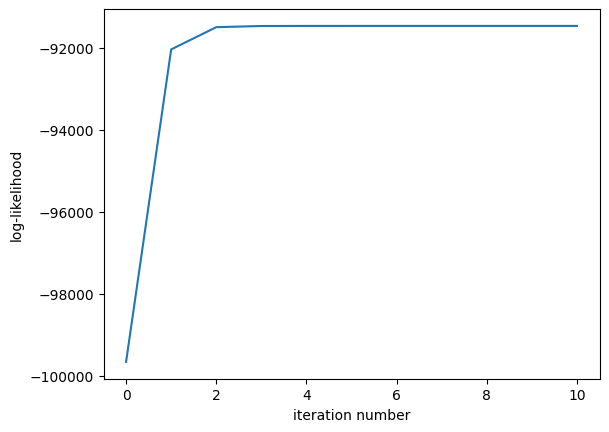

In [8]:
# marginal log-likelihood improves in each iteration
plt.plot(model.ll_history)
labs = plt.gca().set(xlabel = "iteration number", ylabel = "log-likelihood")

# On Real Data

In [10]:
dataset = "email-enron"
H = xgi.load_xgi_data(dataset)
GH = m.GrowingHypergraph(H)

In [11]:
model = em.EM(ll.guaranteed_edge_sample_likelihood,
              ll.nodes_from_hypergraph_likelihood,
              ll.novel_nodes_likelihood)

# time to fit the model
model.fit(GH)

Step 0: marginal ll = -80348.52115912047
Step 1: marginal ll = -77268.53095567315
Step 2: marginal ll = -76965.01788684439
Step 3: marginal ll = -76929.20313098075
Step 4: marginal ll = -76924.69758376708
Step 5: marginal ll = -76924.12512606362
Step 6: marginal ll = -76924.05189672837
Step 7: marginal ll = -76924.04236696681
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/pchodrow/.conda/envs/hypermech/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3505, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_79761/3582739329.py", line 6, in <module>
    model.fit(GH)
  File "/storage/homes/pchodrow/HyperGraph/code/src/em.py", line 44, in fit
    self.M_step()
  File "/storage/homes/pchodrow/HyperGraph/code/src/em.py", line 158, in M_step
    self.pars["eta"] = self.edge_sample_likelihood.m_step(self.intersection_sizes, self.edge_sizes[np.newaxis,:], self.CHI)
  File "/storage/homes/pchodrow/HyperGraph/code/src/likelihoods.py", line 87, in guaranteed_edge_sample_m_step
  File "/home/pchodrow/.conda/envs/hypermech/lib/python3.10/site-packages/numpy/core/_methods.py", line 49, in _sum
    return umr_sum(a, axis, dtype, out, keepdims, initial, where)
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most r

In [11]:
model.pars

{'eta': 0.8793384884211186,
 'beta': 0.013137344970142397,
 'gamma': 0.12041943567380488}

In [12]:
1 + (model.pars["gamma"] + model.pars["beta"]) / (1 - model.pars["eta"])

2.1068714364367604

In [29]:
(GH.edge_size_sequence() == 2).mean()

0.7294441892512632

{1, 7}